In [1]:
%matplotlib ipympl
# from stage 1
import scipy.io as spio
import numpy as np
import scipy.special 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# filter
from scipy.signal import butter,filtfilt

# spike detection
from scipy.signal import find_peaks

# PCA
from sklearn.decomposition import PCA

# classifier
# import all packages needed to run the code
from sklearn import metrics
import scipy.interpolate as interp
from sklearn.model_selection import train_test_split
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, MaxPooling1D
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical

# save
from scipy.io import savemat

# Filter Functions

In [2]:
def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], analog=False, btype='band')
        y = filtfilt(b, a, data)
        return y

In [3]:
def butter_lowpass_filter(data, cutoff, fs, order=5):
        nyq = 0.5 * fs
        low = cutoff / nyq
        b, a = butter(order, low, analog=False, btype='low')
        y = filtfilt(b, a, data)
        return y

In [4]:
# function to normalise data
def NormaliseData(inData):
    """ Normalise array

    Normalise input and target data

    :param: inData - numpy array of input data

    :return: inData - numpy array of normalised input data
    """

    inData = inData.astype("float32") / 255

    max_val = max(inData)
    min_val = min(inData)
    range_val = max_val - min_val 

    normData = inData.copy()
    j = 0
    for i in inData:
        normData[j] = (i - min_val)/range_val 

    return normData

# Load Data

D1: This is a low noise recording that is fully labelled, it has both Index and Class vectors that are
correct. You should use this for training your classifier. <br>
D2: This is a low noise recording that does not contain labels (i.e., it only contains the d vector). <br>
D3: This is a high noise recording that does not contain labels (i.e., it only contains the d vector). <br>
D4: This is a high noise recording that does not contain labels (i.e., it only contains the d vector). <br>

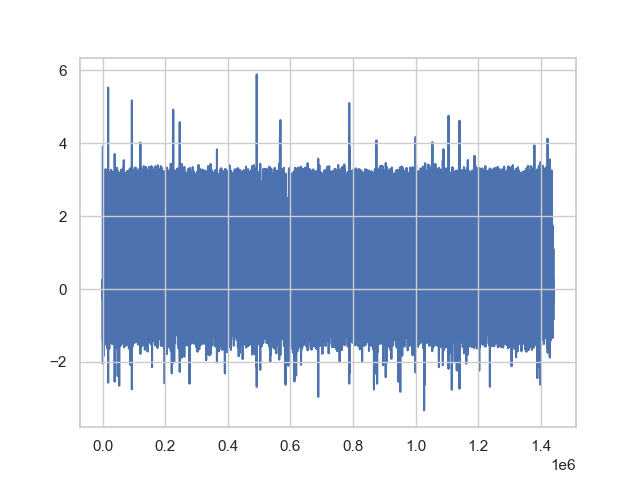

In [5]:
mat = spio.loadmat('D1.mat', squeeze_me=True)
d1 = mat['d'] # Raw time domain recording (1440000 samples), 25 kHz sampling frequency.
Index1 = mat['Index'] # The location in the recording (in samples) of the start of each spike.
Class1 = mat['Class'] # The class (1, 2, 3, 4 or 5), i.e the type of neuron that generated each spike.

plt.figure(0)
plt.plot(d1)

# Filter - better for peak detection (from sub3).
fs = 25000      # sample rate, Hz
order = 1       # sin wave can be approx represented as quadratic
lowcut = 300 # 300, 250
highcut  = 3000 #3000, 4050

# Filter
d1_f = butter_bandpass_filter(d1, lowcut, highcut, fs, order)

plt.figure(0)
plt.cla()
plt.clf()
plt.plot(d1_f, zorder=-1)

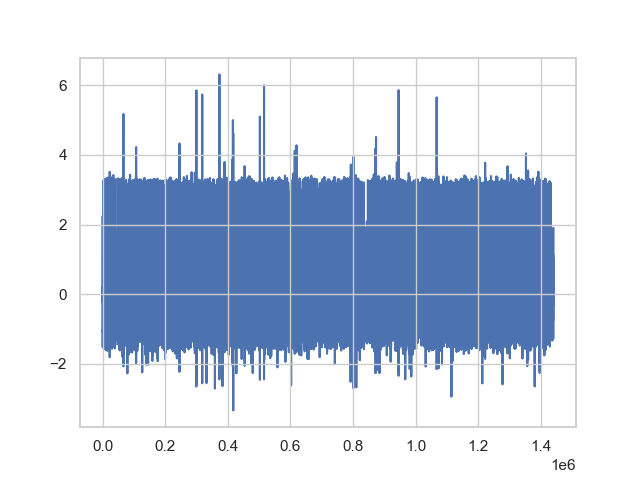

In [6]:
# Load dataset D2 into Python
mat = spio.loadmat('D2.mat', squeeze_me=True)
d2 = mat['d']
mat = spio.loadmat('class2_test.mat', squeeze_me=True)
class2_test = mat['class_test']

plt.figure(1)
plt.plot(d2)

# Filter
d2_f = butter_bandpass_filter(d2, lowcut, highcut, fs, order)

plt.figure(1)
plt.cla()
plt.clf()
plt.plot(d2_f, zorder=-1)

Unhandled message type set_device_pixel_ratio. {'device_pixel_ratio': 1.5, 'type': 'set_device_pixel_ratio'}


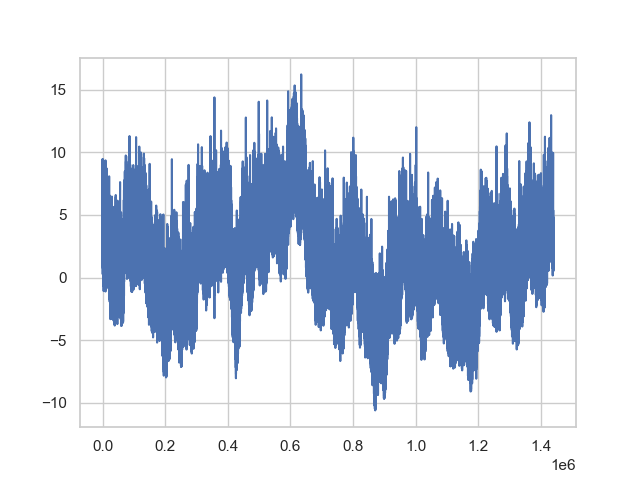

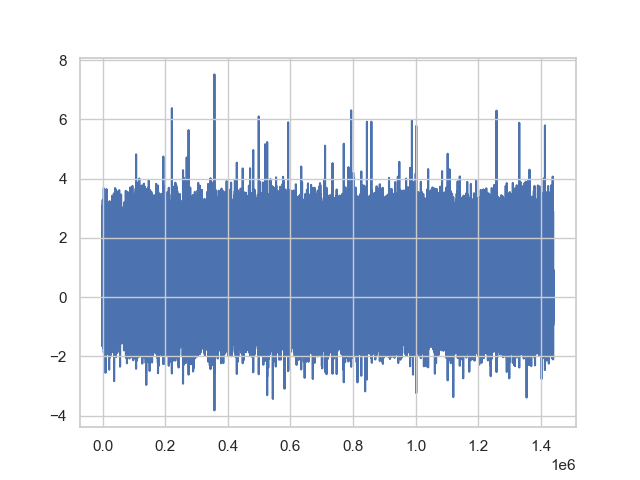

In [7]:
# Load dataset D3 into Python
mat = spio.loadmat('D3.mat', squeeze_me=True)
d3 = mat['d']

plt.figure(2)
plt.plot(d3)

# Filter
d3_f = butter_bandpass_filter(d3, lowcut, highcut, fs, order)

plt.figure(3)
plt.plot(d3_f, zorder=-1)

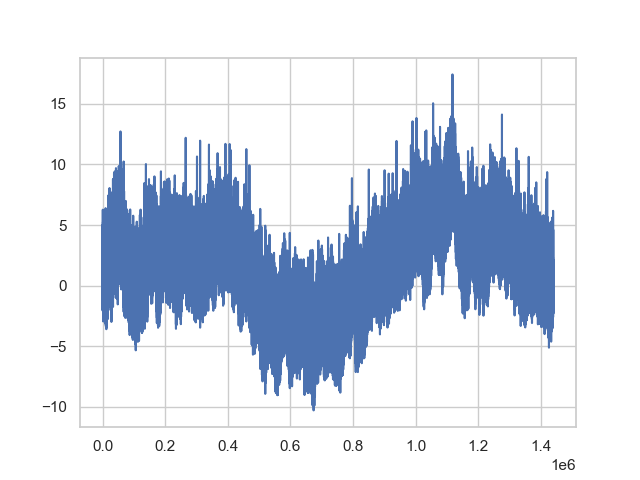

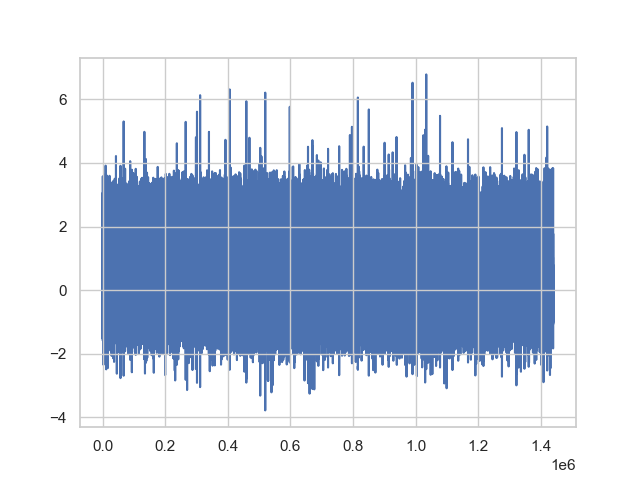

In [8]:
# Load dataset D2 into Python
mat = spio.loadmat('D4.mat', squeeze_me=True)
d4 = mat['d']

plt.figure(4)
plt.plot(d4)

d4_f = butter_bandpass_filter(d4, lowcut, highcut, fs, order)

plt.figure(5)
plt.plot(d4_f, zorder=-1)

# Spike Detection

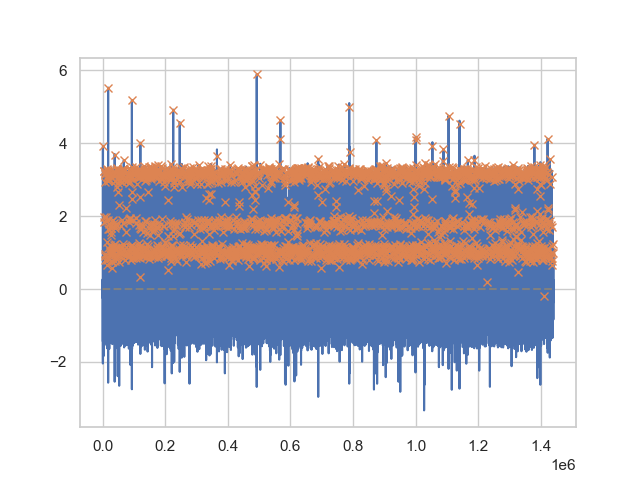

In [9]:
# calculate standard deviation of signal using Donoho's estimation
# std = (np.median(abs(d1 - np.mean(d1))/0.6745))
std = (np.median(abs(d1)/0.6745))

# spike detection threshold
ts = std*3 # some papers use 5*std

peaks1, _ = find_peaks(d1, prominence=1.6, height = ts)
# peaks1, _ = find_peaks(d1, height = ts)

plt.figure(6)
plt.plot(d1_f)
plt.plot(peaks1, d1_f[peaks1], "x")
plt.plot(np.zeros_like(d1), "--", color="gray")
plt.show()

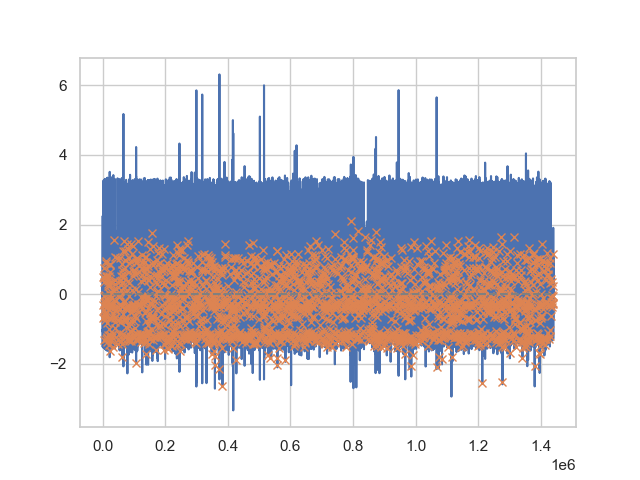

In [10]:
# calculate standard deviation of signal using Donoho's estimation
# std2 = (np.median(abs(d2 - np.mean(d2))/0.6745))
std2 = (np.median(abs(d2)/0.6745))

# spike detection threshold
ts2 = std2*3 # some papers use 5*std

peaks2, _ = find_peaks(d2, prominence=1.6, height=ts2)
# peaks2, _ = find_peaks(d2, height=ts2)

Index2 = peaks2.copy()
for i in range(len(Index2)):
    Index2[i] = Index2[i] - 10

plt.figure(7)
plt.plot(d2_f)
plt.plot(Index2, d2_f[Index2], "x")
plt.plot(np.zeros_like(d2), "--", color="gray")
plt.show()    

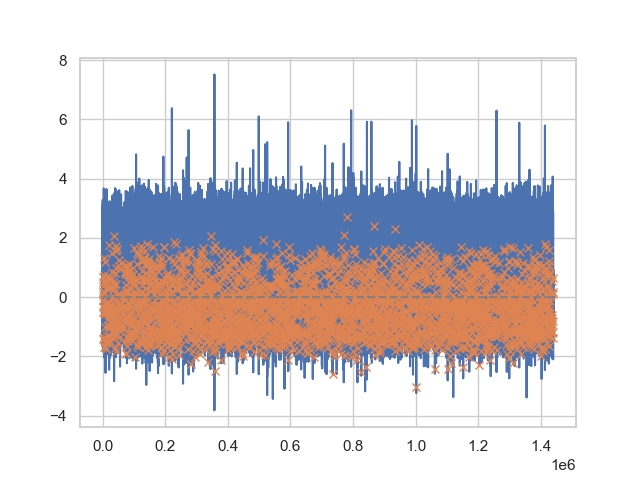

In [11]:
# calculate standard deviation of signal using Donoho's estimation
# std3 = (np.median(abs(d3_f - np.mean(d3_f))/0.6745))
std3 = (np.median(abs(d3_f)/0.6745))
# spike detection threshold
ts3 = std3*3 # some papers use 5*std

peaks3, _ = find_peaks(d3_f, prominence=1.6, height=ts3)
# peaks3, _ = find_peaks(d3_f, height=ts3)

Index3 = peaks3.copy()
for i in range(len(Index3)):
    Index3[i] = Index3[i] - 10

plt.figure(8)
plt.plot(d3_f)
plt.plot(Index3, d3_f[Index3], "x")
plt.plot(np.zeros_like(d3_f), "--", color="gray")
plt.show()  

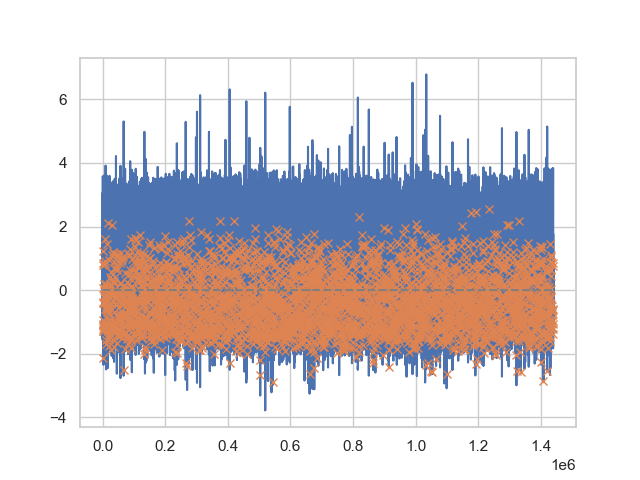

In [12]:
# calculate standard deviation of signal using Donoho's estimation
# std4 = (np.median(abs(d4_f - np.mean(d4_f))/0.6745))
std4 = (np.median(abs(d4_f)/0.6745))

# spike detection threshold
ts4 = std4*3 # some papers use 5*std

peaks4, _ = find_peaks(d4_f, prominence=1.6, height=ts4)
# peaks4, _ = find_peaks(d4_f, height=ts4)

Index4 = peaks4.copy()
for i in range(len(Index4)):
    Index4[i] = Index4[i] - 10

plt.figure(9)
plt.plot(d4_f)
plt.plot(Index4, d4_f[Index4], "x")
plt.plot(np.zeros_like(d4_f), "--", color="gray")
plt.show() 

In [13]:
# Sort index and class
Index1_sorted, Class1_sorted = zip(*sorted(zip(Index1, Class1)))
Index2_sorted = sorted(Index2)
Index3_sorted = sorted(Index3)
Index4_sorted = sorted(Index4)

# Define period of each spike
n_2ms = int((25e3) * 2e-3) # int((25e3)/downsample_factor * 2e-3) # 50 for 25kHz 
if n_2ms%2 != 0:
    n_2ms = n_2ms - 1
n = int((25e3) * 0.5e-3) #int(n_2ms/2)
if n%2 != 0:
    n = n - 1
# spike = np.zeros([n_2ms,len(Index1)])
# spike2 = np.zeros([n_2ms,len(Index2)])
# spike3 = np.zeros([n_2ms,len(Index3)])
# spike4 = np.zeros([n_2ms,len(Index4)])

d1_n = NormaliseData(d1_f)
d2_n = NormaliseData(d2_f)
d3_n = NormaliseData(d3_f)
d4_n = NormaliseData(d4_f)

spike = np.zeros([n_2ms+n,len(Index1)])
spike2 = np.zeros([n_2ms+n,len(Index2)])
spike3 = np.zeros([n_2ms+n,len(Index3)])
spike4 = np.zeros([n_2ms+n,len(Index4)])

# Set up arrays for neural network d1
k = 0
for i in range(n,len(d1)-n_2ms):
    if k < len(Index1_sorted) and i == Index1_sorted[k]:
        spike[:,k] = d1_n[i-n:i+n_2ms]
        # spike[:,k] = d1_n[i:i+n_2ms]
        k = k + 1

# Set up arrays for neural network d2
k = 0
for i in range(n,len(d2)-n_2ms):
    if k < len(Index2_sorted) and i == Index2_sorted[k]:
        spike2[:,k] = d2_n[i-n:i+n_2ms]
        # spike2[:,k] = d2_n[i:i+n_2ms]
        k = k + 1 

# Set up arrays for neural network d3
k = 0
for i in range(n,len(d3_f)-n_2ms):
    if k < len(Index3_sorted) and i == Index3_sorted[k]:
        spike3[:,k] = d3_n[i-n:i+n_2ms]
        # spike3[:,k] = d3_n[i:i+n_2ms]
        k = k + 1 

# Set up arrays for neural network d4
k = 0
for i in range(n,len(d4_f)-n_2ms):
    if k < len(Index4_sorted) and i == Index4_sorted[k]:
        spike4[:,k] = d4_n[i-n:i+n_2ms]
        # spike4[:,k] = d4_n[i:i+n_2ms]
        k = k + 1 

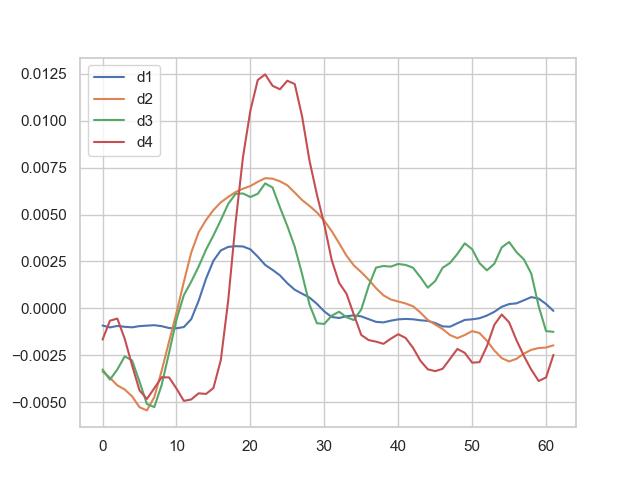

In [14]:
plt.figure(10)
plt.cla()
plt.clf()
plt.plot(spike[:,8])
plt.plot(spike2[:,6])
plt.plot(spike3[:,6])
plt.plot(spike4[:,6])
plt.legend(['d1', 'd2', 'd3', 'd4'], loc='upper left') #, 'd3', 'd4'
plt.show() 

# Dimension Reduction

In [15]:
# training
x = len(spike[0])
d1_spikes_train = spike[:,0:int(x*0.8)].transpose()
d1_spikes_test = spike[:,int(x*0.8):].transpose()
d2_spikes_test = spike2.transpose()
d3_spikes_test = spike3.transpose()
d4_spikes_test = spike4.transpose()
class1_train = Class1_sorted[0:int(x*0.8)]
class1_test = Class1_sorted[int(x*0.8):]

print(d1_spikes_train.shape)
print(d1_spikes_test.shape)
print(d2_spikes_test.shape)
print(d3_spikes_test.shape)
print(d4_spikes_test.shape)

(2202, 62)
(551, 62)
(2322, 62)
(3387, 62)
(3620, 62)


Total Variance Explained:  0.8948140936747923


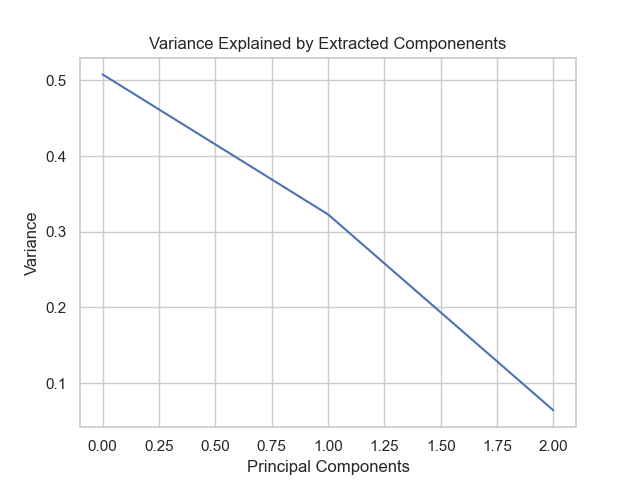

In [16]:
# Select number of components to extract
pca_num = 3
pca = PCA(n_components = pca_num)
# Fit to the training data
pca.fit(d1_spikes_train)

# Determine amount of variance explained by components
print("Total Variance Explained: ", np.sum(pca.explained_variance_ratio_))

# Plot the explained variance
plt.figure(10)
plt.cla()
plt.clf()
plt.plot(pca.explained_variance_ratio_)
plt.title('Variance Explained by Extracted Componenents')
plt.ylabel('Variance')
plt.xlabel('Principal Components')
plt.show()

# Classifier

In [17]:
# Extract the principal components from the training data
train_ext = pca.fit_transform(d1_spikes_train)
# Transform the test data using the same components
test_ext = pca.transform(d1_spikes_test)
test_ext2 = pca.transform(d2_spikes_test)
test_ext3 = pca.transform(d3_spikes_test)
test_ext4 = pca.transform(d4_spikes_test)

Feature shape: (3, 1)
Epoch 1/110
89/89 [==============================] - 2s 8ms/step - loss: 1.8144 - accuracy: 0.2220 - val_loss: 1.7169 - val_accuracy: 0.1950
Epoch 2/110
89/89 [==============================] - 0s 1ms/step - loss: 1.6812 - accuracy: 0.2056 - val_loss: 1.6390 - val_accuracy: 0.1950
Epoch 3/110
89/89 [==============================] - 0s 1ms/step - loss: 1.6358 - accuracy: 0.2061 - val_loss: 1.6233 - val_accuracy: 0.1950
Epoch 4/110
89/89 [==============================] - 0s 1ms/step - loss: 1.6358 - accuracy: 0.1851 - val_loss: 1.6193 - val_accuracy: 0.1950
Epoch 5/110
89/89 [==============================] - 0s 1ms/step - loss: 1.6297 - accuracy: 0.2022 - val_loss: 1.6167 - val_accuracy: 0.2154
Epoch 6/110
89/89 [==============================] - 0s 1ms/step - loss: 1.6334 - accuracy: 0.1942 - val_loss: 1.6154 - val_accuracy: 0.2154
Epoch 7/110
89/89 [==============================] - 0s 1ms/step - loss: 1.6203 - accuracy: 0.2152 - val_loss: 1.6130 - val_accuracy

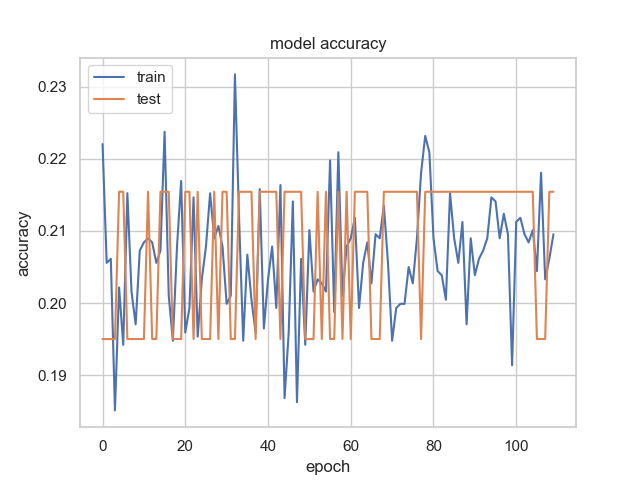

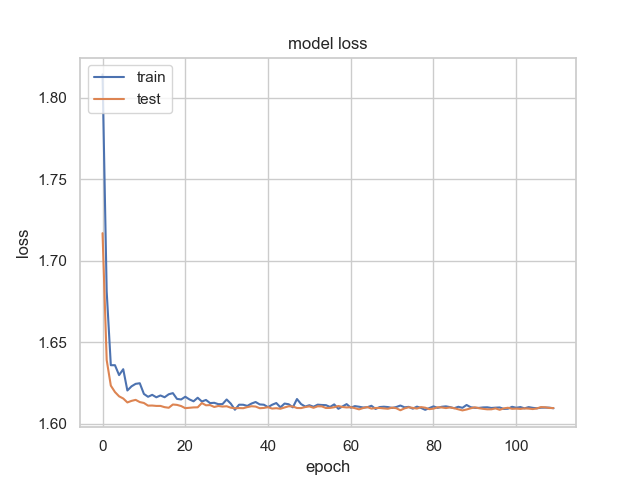

In [18]:
# Configuration options 
feature_vector_length = pca_num
num_classes = 6

# Reshape the data 
X_train = train_ext 
X_test = test_ext 

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Convert target classes to categorical ones
Y_train = to_categorical(class1_train, num_classes)
Y_test = to_categorical(class1_test, num_classes)

# Set the input shape
input_shape = (feature_vector_length,1)
print(f'Feature shape: {input_shape}')

# Create the model
model = Sequential()
model.add(Conv1D(64, 2, activation="relu", input_shape=input_shape, kernel_regularizer='l1'))
model.add(Dense(16, activation="relu"))
model.add(MaxPooling1D())
model.add(Flatten())
model.add(Dropout(0.1))
model.add(Dense(num_classes, activation = 'softmax'))

# Configure the model and start training
optimizer = Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
history = model.fit(X_train, Y_train, epochs=110, batch_size=20, verbose=1, validation_split=0.2) 

# Test the model after training
test_results = model.evaluate(X_test, Y_test, verbose=1)
print(f'Test results - Loss: {test_results[0]} - Accuracy: {test_results[1]}%')

# summarize history for accuracy
plt.figure(13)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for loss
plt.figure(14)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [19]:
# # Test the model after training
test_ext2 = test_ext2.reshape(test_ext2.shape[0], test_ext2.shape[1], 1)
class2_out = model.predict(test_ext2)
Class2 = np.zeros(len(class2_out), dtype=np.int64)
i = 0
n1 = 0
n2 = 0
n3 = 0
n4 = 0
n5 = 0
for l in class2_out:
    Class2[i] = l.argmax()
    
    if Class2[i] == 1:
        n1 = n1 + 1
    elif Class2[i] == 2:
        n2 = n2 + 1   
    elif Class2[i] == 3:
        n3 = n3 + 1
    elif Class2[i] == 4:
        n4 = n4 + 1    
    else:
        n5 = n5 + 1        

    i = i + 1

print("Number of 1s predicted: ", n1)    
print("Number of 2s predicted: ", n2)    
print("Number of 3s predicted: ", n3)    
print("Number of 4s predicted: ", n4)    
print("Number of 5s predicted: ", n5)    


Number of 1s predicted:  2322
Number of 2s predicted:  0
Number of 3s predicted:  0
Number of 4s predicted:  0
Number of 5s predicted:  0


In [20]:
# mdic = {"d": d2, "Index": Index2_sorted, "Class": Class2 }
# savemat("D2_submit.mat", mdic)

In [21]:
# class3_out = model.predict(d3_spikes_test)
test_ext3 = test_ext3.reshape(test_ext3.shape[0], test_ext3.shape[1], 1)
class3_out = model.predict(test_ext3)
Class3 = np.zeros(len(class3_out), dtype=np.int64)
i = 0
n1 = 0
n2 = 0
n3 = 0
n4 = 0
n5 = 0
for l in class3_out:
    Class3[i] = int(l.argmax())

    if Class3[i] == 1:
        n1 = n1 + 1
    elif Class3[i] == 2:
        n2 = n2 + 1   
    elif Class3[i] == 3:
        n3 = n3 + 1
    elif Class3[i] == 4:
        n4 = n4 + 1    
    else:
        n5 = n5 + 1     

    i = i + 1

print("Number of 1s predicted: ", n1)    
print("Number of 2s predicted: ", n2)    
print("Number of 3s predicted: ", n3)    
print("Number of 4s predicted: ", n4)    
print("Number of 5s predicted: ", n5)       

Number of 1s predicted:  3387
Number of 2s predicted:  0
Number of 3s predicted:  0
Number of 4s predicted:  0
Number of 5s predicted:  0


In [22]:
# mdic = {"d": d3, "Index": Index3_sorted, "Class": Class3 }
# savemat("D3_submit.mat", mdic)

In [23]:
# class4_out = model.predict(d4_spikes_test)
test_ext4 = test_ext4.reshape(test_ext4.shape[0], test_ext4.shape[1], 1)
class4_out = model.predict(test_ext4)
Class4 = np.zeros(len(class4_out), dtype=np.int64)
i = 0
n1 = 0
n2 = 0
n3 = 0
n4 = 0
n5 = 0
for l in class4_out:
    Class4[i] = l.argmax()

    if Class4[i] == 1:
        n1 = n1 + 1
    elif Class4[i] == 2:
        n2 = n2 + 1   
    elif Class4[i] == 3:
        n3 = n3 + 1
    elif Class4[i] == 4:
        n4 = n4 + 1    
    else:
        n5 = n5 + 1       
    i = i + 1

print("Number of 1s predicted: ", n1)    
print("Number of 2s predicted: ", n2)    
print("Number of 3s predicted: ", n3)    
print("Number of 4s predicted: ", n4)    
print("Number of 5s predicted: ", n5)       

Number of 1s predicted:  3620
Number of 2s predicted:  0
Number of 3s predicted:  0
Number of 4s predicted:  0
Number of 5s predicted:  0


In [24]:
# mdic = {"d": d4, "Index": Index4_sorted, "Class": Class4 }
# savemat("D4_submit.mat", mdic)